In [1]:
import pandas as pd
import numpy as np
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import f1_score, accuracy_score, classification_report
from xgboost import XGBClassifier
from google.colab import files

warnings.filterwarnings('ignore')

# 1. Load Data
if not os.path.exists('train.csv') or not os.path.exists('test.csv'):
    print("Please upload 'train.csv' and 'test.csv'...")
    uploaded = files.upload()

try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    print("Files loaded successfully!")
except Exception as e:
    print(f"Error loading files: {e}")

# 2. Flexible Feature Engineering
def get_base_engineered_features(df, is_train=True, svd_obj=None):
    """Generates the full feature set before selection."""
    X = df.drop(columns=['id', 'Label'], errors='ignore')

    # Row Stats
    X['bin_sum'] = X.sum(axis=1)
    X['bin_mean'] = X.mean(axis=1)

    # SVD Features
    if is_train:
        svd_obj = TruncatedSVD(n_components=15, random_state=42)
        svd_feats = svd_obj.fit_transform(X)
    else:
        svd_feats = svd_obj.transform(X)

    svd_df = pd.DataFrame(svd_feats, columns=[f'svd_{i}' for i in range(15)], index=X.index)
    X_full = pd.concat([X, svd_df], axis=1)

    # Ensure no negative values for Chi2 (Shift values to positive)
    X_full = X_full - X_full.min().min()

    return X_full, svd_obj

print("Preparing base features...")
y_full = train_df['Label']
X_train_full_raw, svd_m = get_base_engineered_features(train_df, is_train=True)
X_test_full_raw, _ = get_base_engineered_features(test_df, is_train=False, svd_obj=svd_m)

# 3. Tuning Loop: Features + XGBoost Hyperparameters
# We search for the best k (number of features) AND best XGB parameters
k_values = [100, 150, 200, 250] # Number of top features to keep
depths = [6, 10, 12]
lrs = [0.1, 0.05, 0.01]
seeds = [42]

best_f1 = 0
best_acc = 0
best_params = {}

print("\n--- Starting Fine-Tuning (Feature Count + XGBoost) ---")

for k in k_values:
    # Feature Selection for this specific k
    selector = SelectKBest(score_func=chi2, k=min(k, X_train_full_raw.shape[1]))
    X_selected = selector.fit_transform(X_train_full_raw, y_full)

    # Split for validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_selected, y_full, test_size=0.15, random_state=42, stratify=y_full
    )

    for d in depths:
        for lr in lrs:
            for s in seeds:
                model = XGBClassifier(
                    max_depth=d,
                    learning_rate=lr,
                    random_state=s,
                    n_estimators=200,
                    verbosity=0,
                    use_label_encoder=False,
                    eval_metric='logloss'
                )

                model.fit(X_train, y_train)
                preds = model.predict(X_val)

                current_f1 = f1_score(y_val, preds)
                current_acc = accuracy_score(y_val, preds)

                if current_f1 > best_f1:
                    best_f1 = current_f1
                    best_acc = current_acc
                    best_params = {
                        'k': k,
                        'depth': d,
                        'lr': lr,
                        'seed': s,
                        'selector': selector
                    }
                    print(f"New Best found! K_Features: {k}, Depth: {d}, LR: {lr} -> F1: {best_f1*100:.2f}%")

print("\n--- Optimization Complete ---")
print(f"Best Number of Features (k): {best_params['k']}")
print(f"Best Accuracy: {best_acc*100:.2f}%")
print(f"Best F1 Score: {best_f1*100:.2f}%")

# 4. Final Model Training
print("\nTraining final model with best configuration...")

# Transform full training and test data using the best selector found
X_final_train = best_params['selector'].transform(X_train_full_raw)
X_final_test = best_params['selector'].transform(X_test_full_raw)

final_model = XGBClassifier(
    max_depth=best_params['depth'],
    learning_rate=best_params['lr'],
    n_estimators=1000, # Increased for final production
    random_state=best_params['seed'],
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_model.fit(X_final_train, y_full)

# 5. Generate result.csv
print("Predicting on test data...")
test_preds = final_model.predict(X_final_test)

result_df = pd.DataFrame({
    'id': test_df['id'] if 'id' in test_df.columns else np.arange(1, len(test_preds) + 1),
    'Label': test_preds.astype(int)
})

result_df.to_csv('result.csv', index=False)
files.download('result.csv')
print("\nSuccess! 'result.csv' created using the optimized XGBoost model.")

Files loaded successfully!
Preparing base features...

--- Starting Fine-Tuning (Feature Count + XGBoost) ---
New Best found! K_Features: 100, Depth: 6, LR: 0.1 -> F1: 99.45%
New Best found! K_Features: 100, Depth: 10, LR: 0.05 -> F1: 99.56%

--- Optimization Complete ---
Best Number of Features (k): 100
Best Accuracy: 99.30%
Best F1 Score: 99.56%

Training final model with best configuration...
Predicting on test data...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Success! 'result.csv' created using the optimized XGBoost model.


In [2]:
import pandas as pd
import numpy as np
import warnings
import os
import sys
import subprocess
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier # Removed from here
from google.colab import files

# Install catboost if not already installed, then import CatBoostClassifier
try:
    import catboost
    from catboost import CatBoostClassifier
except ImportError:
    print("Installing catboost...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost", "-q"])
    print("Catboost installed. Attempting import again...")
    from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

# 1. Load Data
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
except:
    uploaded = files.upload()
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

# 2. Advanced Feature Engineering for Malware
def get_advanced_features(train, test, n_svd=60):
    y = train['Label']
    X_train_raw = train.drop(columns=['id', 'Label'], errors='ignore')
    X_test_raw = test.drop(columns=['id', 'Label'], errors='ignore')

    # Binary activity features
    for df in [X_train_raw, X_test_raw]:
        df['total_calls'] = df.sum(axis=1)
        df['unique_patterns'] = (df > 0).sum(axis=1)

    # MaxAbsScaler is better for sparse/binary data than StandardScaler
    scaler = MaxAbsScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # TruncatedSVD captures latent malware patterns better than PCA
    svd = TruncatedSVD(n_components=n_svd, random_state=42)
    X_train_svd = svd.fit_transform(X_train_scaled)
    X_test_svd = svd.transform(X_test_scaled)

    # CONCATENATE: Keep raw features + SVD (Don't drop the raw signal!)
    X_train_final = np.hstack((X_train_scaled, X_train_svd))
    X_test_final = np.hstack((X_test_scaled, X_test_svd))

    return X_train_final, X_test_final, y

# 3. Training Logic
N_SVD = 50 # Capture the core 50 latent signals
X_full, X_test_final, y_full = get_advanced_features(train_df, test_df, N_SVD)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
test_probs = []

print(f"--- Training High-Performance Ensemble (Features: {X_full.shape[1]}) ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full)):
    X_tr, X_val = X_full[train_idx], X_full[val_idx]
    y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

    # Imbalance Weight
    spw = len(y_tr[y_tr==0]) / len(y_tr[y_tr==1])

    # 1. XGBoost
    xgb = XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.03,
                        scale_pos_weight=spw, tree_method='hist', random_state=42)

    # 2. LightGBM
    lgbm = LGBMClassifier(n_estimators=1000, max_depth=6, learning_rate=0.03,
                          scale_pos_weight=spw, random_state=42, verbosity=-1)

    # 3. CatBoost (Expert at handling integer/binary malware data)
    cat = CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.03,
                             auto_class_weights='Balanced', verbose=0, random_seed=42)

    # Fit all
    xgb.fit(X_tr, y_tr)
    lgbm.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)

    # Weighted Soft Voting: Give CatBoost and XGBoost more weight
    p_xgb = xgb.predict_proba(X_val)[:, 1]
    p_lgbm = lgbm.predict_proba(X_val)[:, 1]
    p_cat = cat.predict_proba(X_val)[:, 1]

    # Combining: 40% CatBoost, 40% XGBoost, 20% LightGBM
    combined_val_prob = (0.4 * p_cat) + (0.4 * p_xgb) + (0.2 * p_lgbm)
    preds = (combined_val_prob > 0.5).astype(int)

    score = f1_score(y_val, preds)
    fold_scores.append(score)
    print(f"Fold {fold+1} F1: {score*100:.4f}%")

    # Predict on Test
    p_test_xgb = xgb.predict_proba(X_test_final)[:, 1]
    p_test_lgbm = lgbm.predict_proba(X_test_final)[:, 1]
    p_test_cat = cat.predict_proba(X_test_final)[:, 1]
    test_probs.append((0.4 * p_test_cat) + (0.4 * p_test_xgb) + (0.2 * p_test_lgbm))

# 4. Final Aggregation
print(f"\nMean CV F1: {np.mean(fold_scores)*100:.4f}%")

avg_test_prob = np.mean(test_probs, axis=0)
final_labels = (avg_test_prob > 0.5).astype(int)

# 5. Generate Submission
result = pd.DataFrame({
    'id': test_df['id'] if 'id' in test_df.columns else np.arange(1, len(final_labels) + 1),
    'Label': final_labels
})

result.to_csv('final_submission.csv', index=False)
files.download('final_submission.csv')

Installing catboost...
Catboost installed. Attempting import again...
--- Training High-Performance Ensemble (Features: 293) ---
Fold 1 F1: 99.4220%
Fold 2 F1: 99.2519%
Fold 3 F1: 99.7523%
Fold 4 F1: 99.3367%
Fold 5 F1: 99.3399%

Mean CV F1: 99.4205%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== 1. Loading and Scaling Data ===
Original Dataset Dimensions: 241 features.

=== 2. Grid Searching Lasso Penalties for Top 75 Features ===
Successfully extracted top 75 features via L1 Grid Search Optimization.

=== 3. Target Class Imbalance Analysis ===
Class Distribution:
  Class 1.0: 3030 samples (79.86%)
  Class 0.0: 764 samples (20.14%)


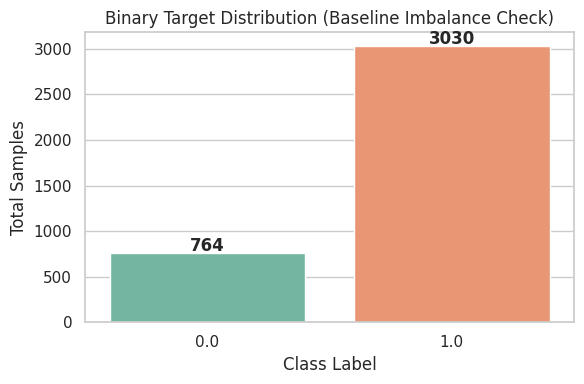


=== 4. Missing Values Check ===
Total Missing Values in Reduced Dataset: 0

=== 5. Class Separation Statistics (Top 10 Features of the 75) ===
                                                     count      mean  \
BATTERY_STATS                                       3794.0  0.080917   
WRITE_CONTACTS                                      3794.0  0.038745   
READ_CALL_LOG                                       3794.0  0.027939   
ACCESS_COARSE_UPDATES                               3794.0  0.007644   
Landroid/location/LocationManager;->getLastK0wn...  3794.0  0.121244   
ACCESS_FINE_LOCATION                                3794.0  0.087507   
BLUETOOTH                                           3794.0  0.046389   
READ_CONTACTS                                       3794.0  0.149974   
SYSTEM_ALERT_WINDOW                                 3794.0  0.397733   
CHANGE_WIFI_STATE                                   3794.0  0.273063   

                                                         std  m

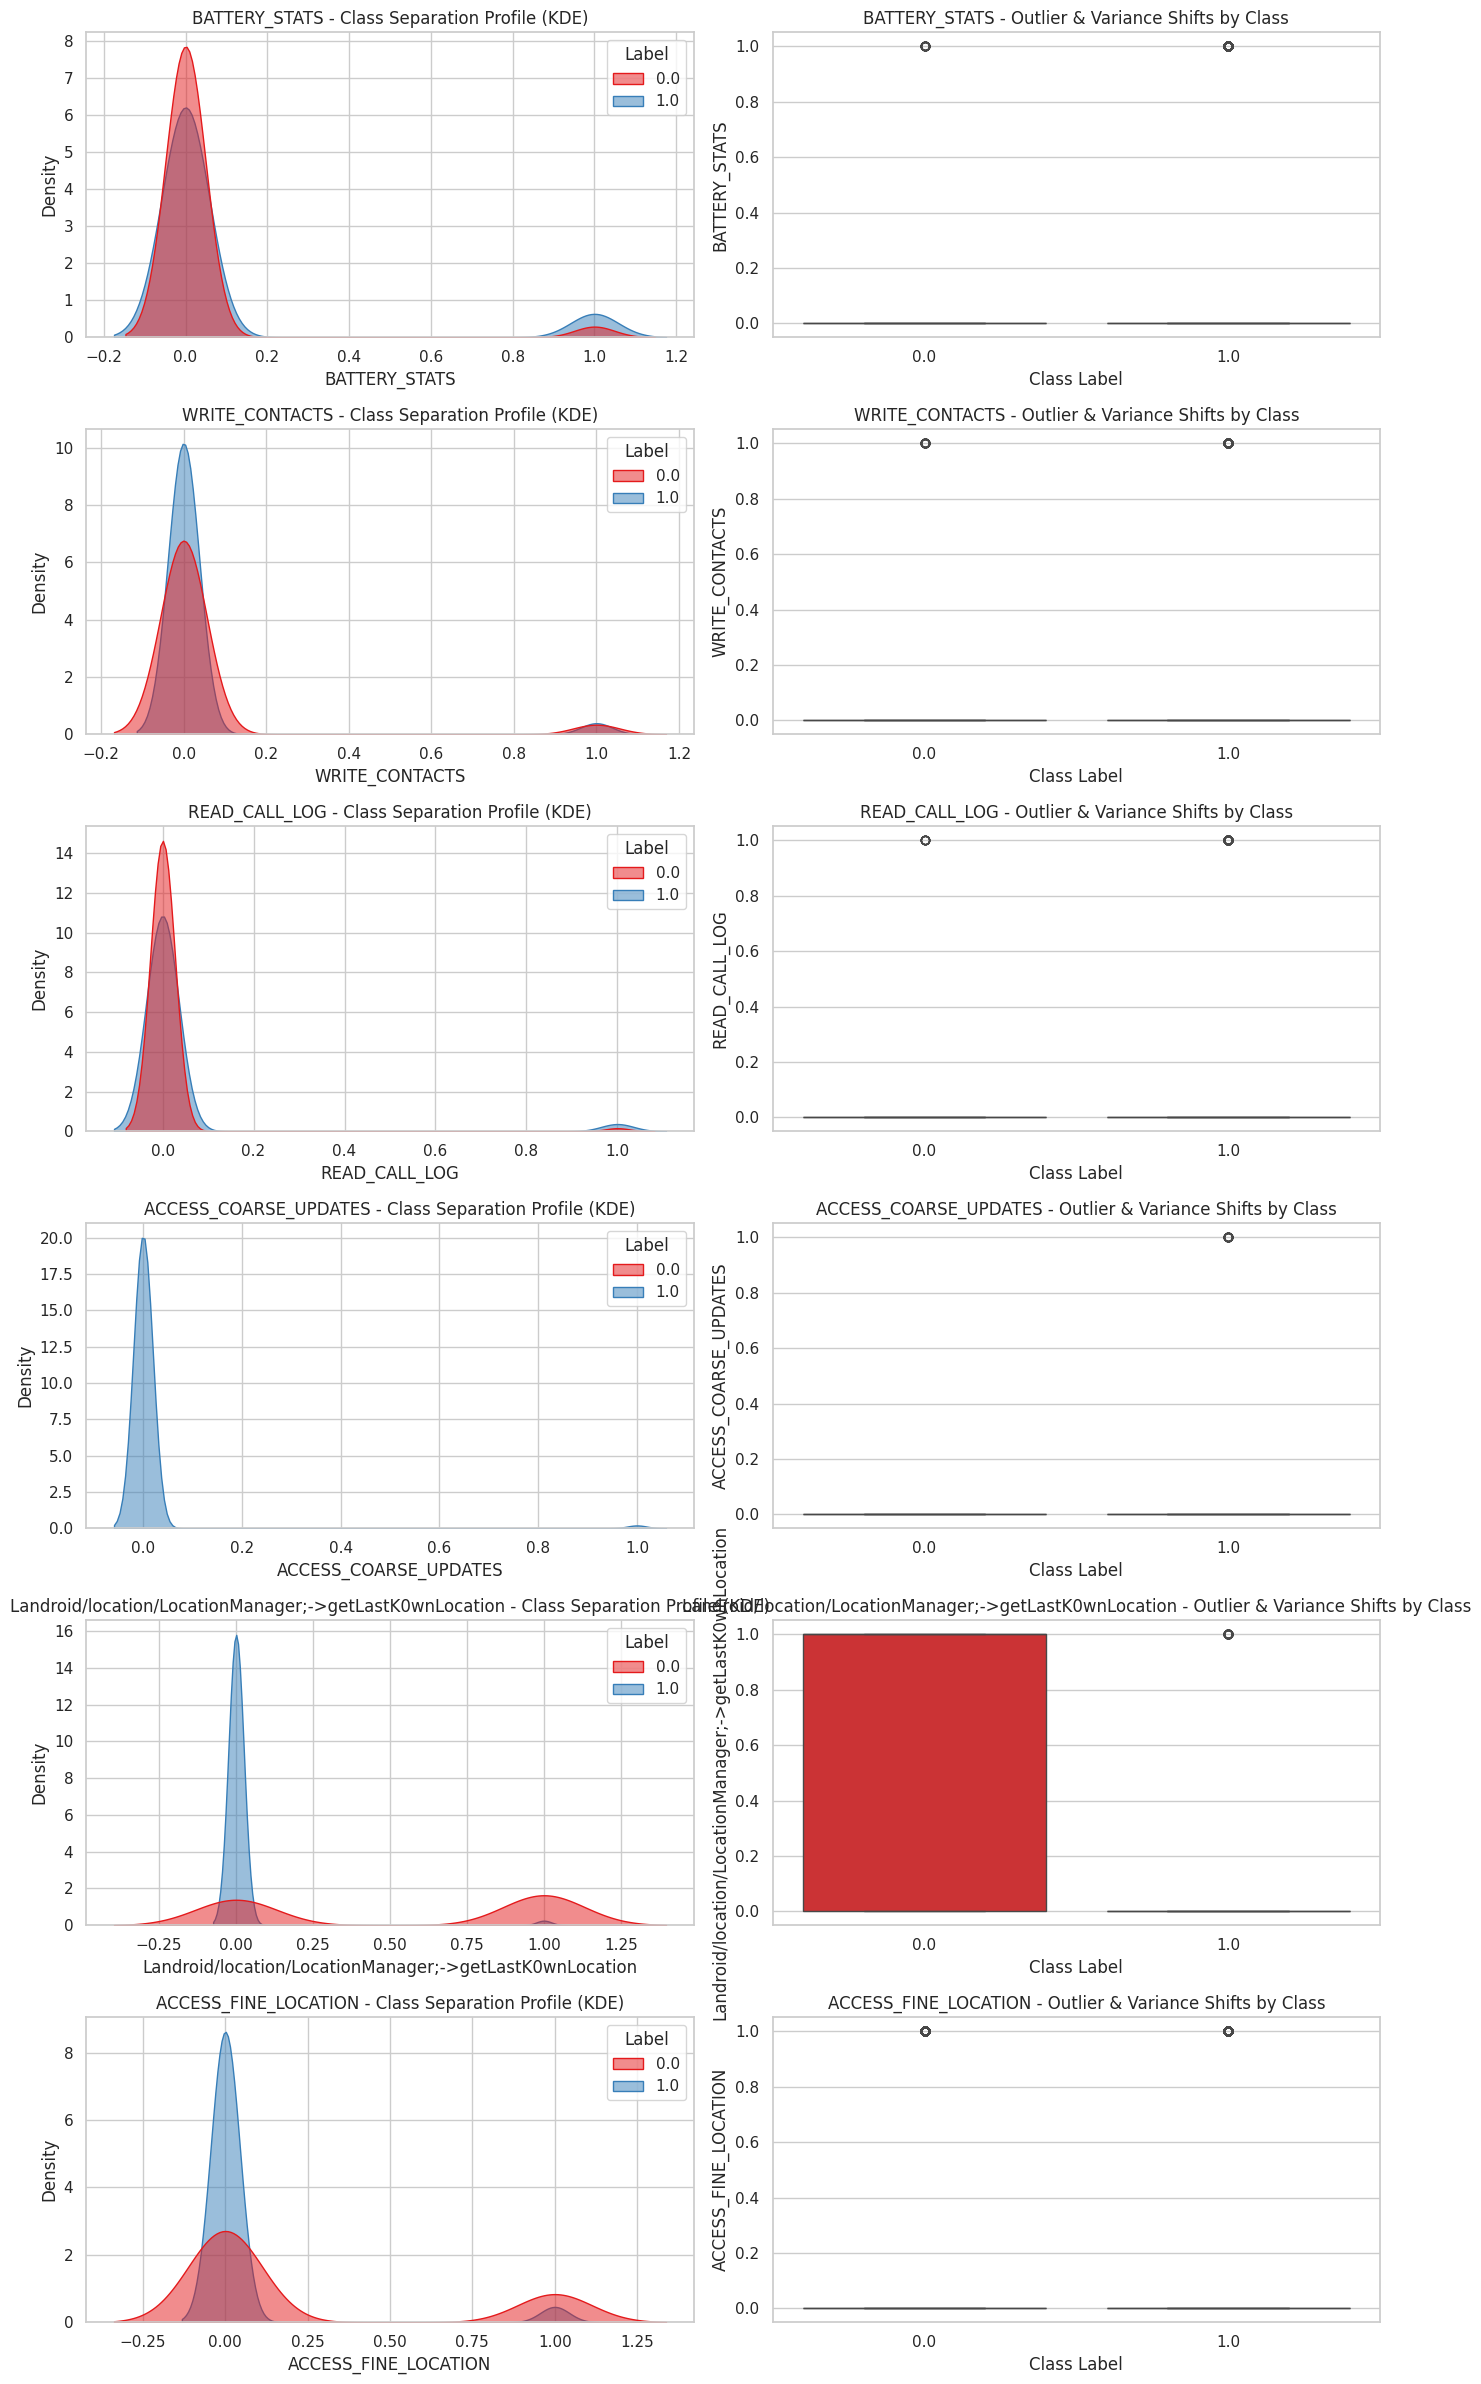


=== 6. Multi-Collinearity & Target Correlation ===

Top 15 Linear Correlation Coefficients with 'Label' (Out of 75 features):
RECEIVE_BOOT_COMPLETED                               0.761195
GET_TASKS                                            0.560661
WAKE_LOCK                                            0.477365
KILL_BACKGROUND_PROCESSES                            0.437488
SYSTEM_ALERT_WINDOW                                  0.280488
RECEIVE_SMS                                          0.179688
READ_PHONE_STATE                                     0.179014
READ_SMS                                             0.127187
CHANGE_WIFI_STATE                                    0.120406
Landroid/telephony/TelephonyManager;->getDeviceId    0.113495
Landroid/telephony/SmsManager;->sendTextMessage      0.097058
CAMERA                                               0.094470
BATTERY_STATS                                        0.083921
Landroid/hardware/Camera;->takePicture               0.080879
BIND_

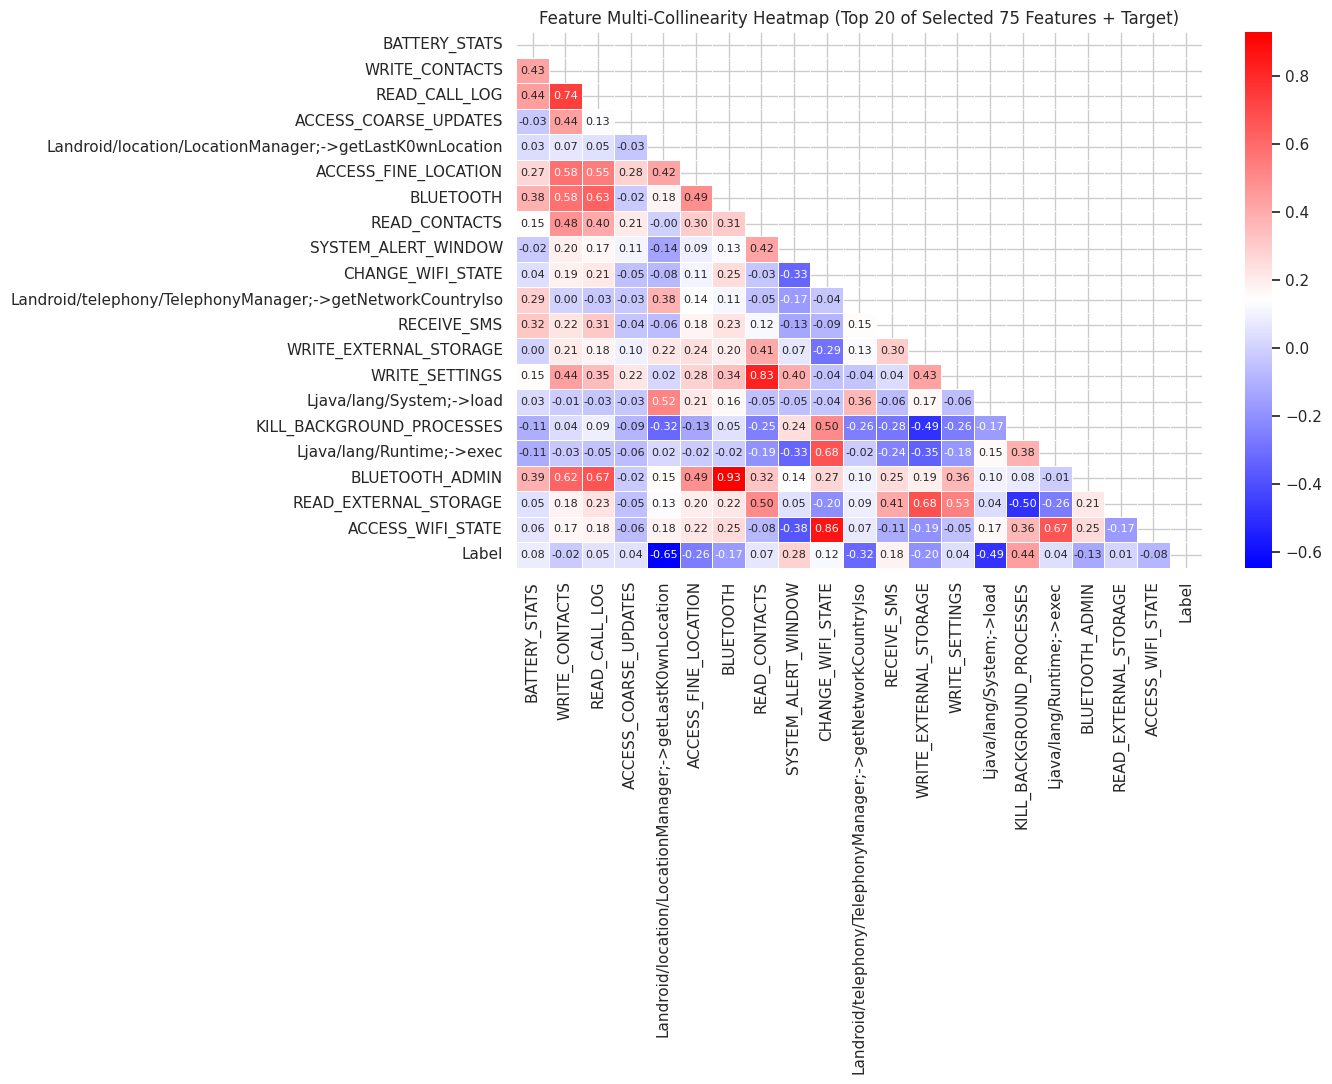


=== Binary EDA on Reduced 75-Feature Dataset Complete! ===


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Set style for high-contrast binary classification visualization
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ==========================================
# 1. LOAD DATA & PREPROCESSING
# ==========================================
print("=== 1. Loading and Scaling Data ===")
df = pd.read_csv("train.csv")
target_col = "Label"

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in train.csv.")

X = df.drop(columns=[target_col])
y = df[target_col]

# Convert categorical columns to dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Original Dataset Dimensions: {X_encoded.shape[1]} features.")

# Scale features (essential for fair L1 regularization penalties)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# ==========================================
# 2. GRID SEARCH FOR FEATURE SELECTION (L1 / LASSO)
# ==========================================
print("\n=== 2. Grid Searching Lasso Penalties for Top 75 Features ===")

# Grid search across 30 different regularization strengths (C)
param_grid = {"C": np.logspace(-3, 1, 30)}
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Imbalance-aware L1 Logistic Regression (handles the 80/20 split via class weights)
log_reg = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=skf,
    scoring="f1_weighted",
    n_jobs=-1
)
grid_search.fit(X_scaled, y)

# Rank features by their absolute coefficient impact weights
best_model = grid_search.best_estimator_
coefficients = np.abs(best_model.coef_[0])

# Isolate the top 75 features
indices = np.argsort(coefficients)[::-1][:75]
top_75_features = X_encoded.columns[indices].tolist()

print(f"Successfully extracted top {len(top_75_features)} features via L1 Grid Search Optimization.")

# Create the new reduced dataframe
df_reduced = X_encoded[top_75_features].copy()
df_reduced[target_col] = y.values

# ==========================================
# 3. BINARY CLASS IMBALANCE ANALYSIS
# ==========================================
print("\n=== 3. Target Class Imbalance Analysis ===")
target_counts = df_reduced[target_col].value_counts()
target_pct = df_reduced[target_col].value_counts(normalize=True) * 100

print("Class Distribution:")
for val in target_counts.index:
    print(f"  Class {val}: {target_counts[val]} samples ({target_pct[val]:.2f}%)")

plt.figure(figsize=(6, 4))
# High contrast palette to clearly highlight the minority class vs majority class
ax = sns.countplot(data=df_reduced, x=target_col, hue=target_col, palette="Set2", legend=False)
plt.title("Binary Target Distribution (Baseline Imbalance Check)")
plt.xlabel("Class Label")
plt.ylabel("Total Samples")

# Add count labels on top of the bars for quick scanning
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 4. MISSING VALUES CHECK
# ==========================================
print("\n=== 4. Missing Values Check ===")
missing_data = df_reduced.isnull().sum().sum()
print(f"Total Missing Values in Reduced Dataset: {missing_data}")

num_cols = df_reduced.drop(columns=[target_col]).select_dtypes(include=[np.number]).columns.tolist()

# ==========================================
# 5. BINARY CLASS SEPARATION ANALYSIS (TOP 6 FEATURES)
# ==========================================
if num_cols:
    print("\n=== 5. Class Separation Statistics (Top 10 Features of the 75) ===")
    print(df_reduced[num_cols[:10]].describe().T)

    # Isolate the top 6 features to plot binary separation profiles
    cols_to_plot = num_cols[:6]
    print(f"\nPlotting binary separation profiles for: {cols_to_plot}")

    fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=2, figsize=(14, 4 * len(cols_to_plot)))
    if len(cols_to_plot) == 1:
        axes = np.array([axes])

    for i, col in enumerate(cols_to_plot):
        # 1. Continuous Density Plot (KDE) - Scales both curves independently to their own sample sizes
        sns.kdeplot(data=df_reduced, x=col, hue=target_col, fill=True, common_norm=False, ax=axes[i, 0], palette="Set1", alpha=0.5)
        axes[i, 0].set_title(f"{col} - Class Separation Profile (KDE)")
        axes[i, 0].set_xlabel(col)

        # 2. Binary Boxplot - Reveals median shifts and outlier differences between Class 0 and 1
        sns.boxplot(data=df_reduced, x=target_col, y=col, ax=axes[i, 1], palette="Set1", hue=target_col, legend=False)
        axes[i, 1].set_title(f"{col} - Outlier & Variance Shifts by Class")
        axes[i, 1].set_xlabel("Class Label")
        axes[i, 1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

# ==========================================
# 6. BINARY CORRELATION PROFILING (TOP 20 FEATURES)
# ==========================================
if len(num_cols) > 1:
    print("\n=== 6. Multi-Collinearity & Target Correlation ===")

    # Calculate complete correlation matrix for all 75 features to pull exact text insights
    full_corr_matrix = df_reduced.corr()

    if target_col in full_corr_matrix.columns:
        print(f"\nTop 15 Linear Correlation Coefficients with '{target_col}' (Out of 75 features):")
        print(full_corr_matrix[target_col].sort_values(ascending=False).iloc[1:16])

    # Isolate the top 20 features to preserve heatmap legibility
    corr_cols = num_cols[:20] + [target_col] if df_reduced[target_col].dtype in [np.int64, np.float64, np.int32] else num_cols[:20]
    sub_corr_matrix = df_reduced[corr_cols].corr()

    plt.figure(figsize=(14, 11))
    mask = np.triu(np.ones_like(sub_corr_matrix, dtype=bool))
    sns.heatmap(sub_corr_matrix, mask=mask, annot=True, cmap="bwr", fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
    plt.title("Feature Multi-Collinearity Heatmap (Top 20 of Selected 75 Features + Target)")
    plt.tight_layout()
    plt.show()

print("\n=== Binary EDA on Reduced 75-Feature Dataset Complete! ===")

In [4]:
# ==========================================
# COLAB PREPARATION: AUTOMATIC ENVIRONMENT SETUP
# ==========================================
import sys
import subprocess

# Ensure CatBoost is available in Colab
try:
    import catboost
except ImportError:
    print("Installing catboost for Google Colab...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost", "-q"])
    import catboost

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ==========================================
# 1. LOAD DATA & EXTRACT TOP 75 FEATURES
# ==========================================
print("=== 1. Loading Data & Performing Lasso Feature Selection ===")
try:
    df_train = pd.read_csv("train.csv")
except FileNotFoundError:
    raise FileNotFoundError("Please upload 'train.csv' to your Google Colab files panel on the left side menu.")

target_col = "Label"

X_train_full = df_train.drop(columns=[target_col])
y_train_full = df_train[target_col]

X_encoded = pd.get_dummies(X_train_full, drop_first=True)

# Scale for fair Lasso penalty distribution
lasso_scaler = StandardScaler()
X_scaled_lasso = lasso_scaler.fit_transform(X_encoded)

# Run L1 Regularization to find the top 75 features
lasso_search = GridSearchCV(
    estimator=LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", random_state=42),
    param_grid={"C": np.logspace(-3, 1, 15)},
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="f1_weighted",
    n_jobs=-1
)
lasso_search.fit(X_scaled_lasso, y_train_full)
coefficients = np.abs(lasso_search.best_estimator_.coef_[0])
top_75_indices = np.argsort(coefficients)[::-1][:75]
top_75_features = X_encoded.columns[top_75_indices].tolist()

print(f"Dataset successfully pruned down to the top {len(top_75_features)} features.")

# Isolate the 75-feature dataset for modeling
X_train_75 = X_encoded[top_75_features].copy()
num_cols = X_train_75.select_dtypes(include=[np.number]).columns.tolist()

if num_cols:
    stack_scaler = StandardScaler()
    X_train_75_scaled = X_train_75.copy()
    X_train_75_scaled[num_cols] = stack_scaler.fit_transform(X_train_75[num_cols])
else:
    X_train_75_scaled = X_train_75

# Calculate exact inverse class balance multipliers for base estimators
count_1 = np.sum(y_train_full == 1)
count_0 = np.sum(y_train_full == 0)
imbalance_ratio = count_1 / count_0

# ==========================================
# 2. DEFINE TUNED HIGH-TIER BASE ESTIMATORS
# ==========================================
print("\n=== 2. Initializing Advanced Base Estimators (4 Boosting Algorithms) ===")

# Base 1: XGBoost
xgb_base = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,
    eval_metric="logloss",
    random_state=42,
    n_jobs=2
)

# Base 2: LightGBM
lgb_base = lgb.LGBMClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

# Base 3: CatBoost
cat_base = CatBoostClassifier(
    iterations=150,
    depth=5,
    learning_rate=0.05,
    auto_class_weights='Balanced',
    verbose=0,
    random_state=42,
    thread_count=2
)

# Base 4: Added Scikit-Learn Gradient Boosting Machine
skgb_base = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

# Combine into base estimator list for Stacking Framework
base_estimators = [
    ('xgb', xgb_base),
    ('lgb', lgb_base),
    ('cat', cat_base),
    ('skgb', skgb_base) # 4th Booster Added
]

# ==========================================
# 3. BUILD AND TUNE META-STACKING PIPELINE
# ==========================================
print("\n=== 3. Tuning Stacking Generalization Stack via 10-Fold GridSearchCV ===")

meta_classifier = LogisticRegression(class_weight="balanced", random_state=42, solver="liblinear")

# UPDATED: K-Fold strategy configured to K=10 for both stacking out-of-fold estimation and hyperparameter tuning
cv_strategy_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

stack_pipeline = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    cv=cv_strategy_10, # Applied K=10 to the inner internal validation loop
    n_jobs=1,
    passthrough=False
)

# Finetune meta-learner threshold constraints and structural parameters via Grid Search
param_grid = {
    'final_estimator__C': [0.01, 0.1, 1.0, 10.0]
}

grid_stack = GridSearchCV(
    estimator=stack_pipeline,
    param_grid=param_grid,
    cv=cv_strategy_10, # Applied K=10 to the outer parameter verification loop
    scoring='f1_macro',
    n_jobs=-1
)

# Generate custom sample weights to handle balance distributions for models that require explicit fit vectors (like skgb)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_full)
grid_stack.fit(X_train_75_scaled, y_train_full, sample_weight=sample_weights)

print(f"Best Stacking Configuration Hyperparameters: {grid_stack.best_params_}")
final_stack_model = grid_stack.best_estimator_

# ==========================================
# 4. OUT-OF-FOLD MINORITY RECOVERY ANALYSIS
# ==========================================
print("\n=== 4. Dynamic Threshold Adjustment for Class 0 Accuracy ===")

# Predict probability profiles across the ensemble space
oof_probs = final_stack_model.predict_proba(X_train_75_scaled)[:, 1]

# Sweep thresholds specifically looking for the highest Macro F1 score
best_threshold = 0.5
best_score = 0
for t in np.arange(0.1, 0.9, 0.01):
    preds = (oof_probs >= t).astype(int)
    score = f1_score(y_train_full, preds, average="macro")
    if score > best_score:
        best_score = score
        best_threshold = t

print(f"Optimal Prediction Decision Threshold set to: {best_threshold:.2f}")
train_preds_binary = (oof_probs >= best_threshold).astype(int)

print("\n================ FINAL 10-FOLD STACK GENERALIZATION PERFORMANCE ================")
print(f"Macro F1-Score: {best_score:.4f}")
print(f"Class 0 (Minority) Recall Score: {recall_score(y_train_full, train_preds_binary, pos_label=0):.4f}")
print("--------------------------------------------------------------------")
print(classification_report(y_train_full, train_preds_binary, digits=4))
print("====================================================================")

# ==========================================
# 5. TEST DATA INFERENCE AND SUBMISSION EXPORT
# ==========================================
print("\n=== 5. Running Inference on test.csv ===")
try:
    df_test = pd.read_csv("test.csv")
except FileNotFoundError:
    raise FileNotFoundError("Please upload 'test.csv' to your Google Colab files panel on the left side menu.")

# Safely conform testing boundaries to match training scheme profiles
X_test_encoded = pd.get_dummies(df_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)
X_test_75 = X_test_encoded[top_75_features].copy()

if num_cols:
    X_test_75[num_cols] = stack_scaler.transform(X_test_75[num_cols])

# Run probabilities through final adjusted stacking decision boundary
test_preds_prob = final_stack_model.predict_proba(X_test_75)[:, 1]
test_preds_binary = (test_preds_prob >= best_threshold).astype(int)

# Format and write submission out
submission_df = pd.DataFrame({
    "Id": np.arange(1, len(df_test) + 1),
    "Label": test_preds_binary
})

submission_df.to_csv("submission.csv", index=False)
print("\nSuccess! Generated 'submission.csv' in your Colab working directory.")
print(submission_df["Label"].value_counts())

=== 1. Loading Data & Performing Lasso Feature Selection ===
Dataset successfully pruned down to the top 75 features.

=== 2. Initializing Advanced Base Estimators (4 Boosting Algorithms) ===

=== 3. Tuning Stacking Generalization Stack via 10-Fold GridSearchCV ===
Best Stacking Configuration Hyperparameters: {'final_estimator__C': 0.1}

=== 4. Dynamic Threshold Adjustment for Class 0 Accuracy ===
Optimal Prediction Decision Threshold set to: 0.15

================ FINAL 10-FOLD STACK GENERALIZATION PERFORMANCE ================
Macro F1-Score: 0.9947
Class 0 (Minority) Recall Score: 0.9948
--------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0     0.9883    0.9948    0.9915       764
         1.0     0.9987    0.9970    0.9979      3030

    accuracy                         0.9966      3794
   macro avg     0.9935    0.9959    0.9947      3794
weighted avg     0.9966    0.9966    0.9966      3794


=== 5.